# EDA 02 - Date Range, Missing Dates, and Temporal Coverage

This notebook checks temporal coverage across the project CSV files: date-like columns, min/max date ranges, inferred frequency, missing daily/monthly/yearly periods, temporal gaps, and record distributions by year/month.

## 1. Setup and file discovery

Define the expected CSV files and locate them recursively from the current working directory. Missing files are recorded instead of causing execution failure.

In [ ]:
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 500)
pd.set_option("display.max_colwidth", 160)

PROJECT_ROOT = Path.cwd()
EXPECTED_FILES = [
    "products.csv",
    "customers.csv",
    "promotions.csv",
    "geography.csv",
    "orders.csv",
    "order_items.csv",
    "payments.csv",
    "shipments.csv",
    "returns.csv",
    "reviews.csv",
    "sales.csv",
    "inventory.csv",
    "web_traffic.csv",
    "sample_submission.csv",
]

DATE_NAME_PATTERN = re.compile(
    r"(date|time|timestamp|created|updated|order_date|ship_date|payment_date|return_date|review_date|signup_date|snapshot_date)",
    re.IGNORECASE,
)
DATE_PARSE_THRESHOLD = 0.80
POOR_PARSE_THRESHOLD = 0.80
LARGE_GAP_DAYS = 45
EXPECTED_SALES_START = pd.Timestamp("2012-07-04")
EXPECTED_SALES_END = pd.Timestamp("2022-12-31")
MAIN_BUSINESS_START = EXPECTED_SALES_START
MAIN_BUSINESS_END = EXPECTED_SALES_END

all_csv_paths = list(PROJECT_ROOT.rglob("*.csv"))
paths_by_name = {}
for path in all_csv_paths:
    paths_by_name.setdefault(path.name, []).append(path)

discovery_rows = []
for filename in EXPECTED_FILES:
    matches = paths_by_name.get(filename, [])
    if matches:
        selected = sorted(matches, key=lambda p: (len(p.parts), str(p)))[0]
        discovery_rows.append({
            "file": filename,
            "status": "found",
            "path": str(selected.relative_to(PROJECT_ROOT)),
            "match_count": len(matches),
        })
    else:
        discovery_rows.append({
            "file": filename,
            "status": "missing",
            "path": None,
            "match_count": 0,
        })

file_discovery_df = pd.DataFrame(discovery_rows)
missing_files_df = file_discovery_df[file_discovery_df["status"] == "missing"].copy()

print(f"Project root: {PROJECT_ROOT}")
print(f"CSV files discovered recursively: {len(all_csv_paths)}")
file_discovery_df

Project root: D:\Code\Datathon 2026
CSV files discovered recursively: 15


,file,status,path,match_count
0,products.csv,found,datathon-2026-round-1\products.csv,1
1,customers.csv,found,datathon-2026-round-1\customers.csv,1
2,promotions.csv,found,datathon-2026-round-1\promotions.csv,1
3,geography.csv,found,datathon-2026-round-1\geography.csv,1
4,orders.csv,found,datathon-2026-round-1\orders.csv,1
5,order_items.csv,found,datathon-2026-round-1\order_items.csv,1
6,payments.csv,found,datathon-2026-round-1\payments.csv,1
7,shipments.csv,found,datathon-2026-round-1\shipments.csv,1
8,returns.csv,found,datathon-2026-round-1\returns.csv,1
9,reviews.csv,found,datathon-2026-round-1\reviews.csv,1


## 2. Load CSV files

Load each available expected CSV safely. Files that are missing or fail to load are represented in the load summary.

In [2]:
loaded = {}
load_rows = []

for _, row in file_discovery_df.iterrows():
    filename = row["file"]
    if row["status"] != "found":
        load_rows.append({"file": filename, "loaded": False, "rows": np.nan, "columns": np.nan, "error": "file missing"})
        continue
    try:
        df = pd.read_csv(PROJECT_ROOT / row["path"], low_memory=False)
        loaded[filename] = df
        load_rows.append({"file": filename, "loaded": True, "rows": len(df), "columns": len(df.columns), "error": ""})
    except Exception as exc:
        load_rows.append({"file": filename, "loaded": False, "rows": np.nan, "columns": np.nan, "error": repr(exc)})

load_summary_df = pd.DataFrame(load_rows)
load_summary_df

,file,loaded,rows,columns,error
0,products.csv,True,2412,8,
1,customers.csv,True,121930,7,
2,promotions.csv,True,50,10,
3,geography.csv,True,39948,4,
4,orders.csv,True,646945,8,
5,order_items.csv,True,714669,7,
6,payments.csv,True,646945,4,
7,shipments.csv,True,566067,4,
8,returns.csv,True,39939,7,
9,reviews.csv,True,113551,7,


## 3. Detect date-like columns across all files

A column is considered date-like if its name suggests a date/time field, if pandas already treats it as datetime, or if a high share of non-null object/string values can be parsed as datetime.

In [3]:
def safe_parse_datetime(series):
    return pd.to_datetime(series, errors="coerce")


def detect_date_like_column(column_name, series):
    name_match = bool(DATE_NAME_PATTERN.search(str(column_name)))
    dtype_datetime = pd.api.types.is_datetime64_any_dtype(series)
    non_null = series.dropna()

    parsed = pd.Series(pd.NaT, index=series.index, dtype="datetime64[ns]")
    parse_success_rate = np.nan

    # Avoid parsing ordinary numeric IDs as datetimes unless the column name itself is date-like.
    should_attempt_parse = (
        name_match
        or dtype_datetime
        or pd.api.types.is_object_dtype(series)
        or pd.api.types.is_string_dtype(series)
    )
    if len(non_null) and should_attempt_parse:
        parsed = safe_parse_datetime(series)
        parse_success_rate = parsed.notna().sum() / len(non_null)

    high_parse_success = bool(pd.notna(parse_success_rate) and parse_success_rate >= DATE_PARSE_THRESHOLD)
    detected = name_match or dtype_datetime or high_parse_success

    reasons = []
    if name_match:
        reasons.append("name_match")
    if dtype_datetime:
        reasons.append("datetime_dtype")
    if high_parse_success:
        reasons.append("high_parse_success")

    return detected, ";".join(reasons), parsed, parse_success_rate


def infer_frequency(parsed_dates):
    dates = pd.Series(parsed_dates).dropna()
    if len(dates) == 0:
        return "unknown"
    unique_dates = pd.Series(pd.to_datetime(dates).dt.normalize().unique()).sort_values()
    if len(unique_dates) < 2:
        return "unknown"

    day_span = (unique_dates.max() - unique_dates.min()).days + 1
    unique_days = len(unique_dates)
    daily_coverage = unique_days / day_span if day_span else 0
    deltas = unique_dates.diff().dropna().dt.days
    median_delta = deltas.median() if len(deltas) else np.nan

    unique_months = pd.PeriodIndex(unique_dates, freq="M").unique()
    month_span = len(pd.period_range(unique_months.min(), unique_months.max(), freq="M")) if len(unique_months) else 0
    monthly_coverage = len(unique_months) / month_span if month_span else 0

    unique_years = pd.Index(unique_dates.dt.year.unique())
    year_span = int(unique_years.max() - unique_years.min() + 1) if len(unique_years) else 0
    yearly_coverage = len(unique_years) / year_span if year_span else 0

    if median_delta <= 1.5 or daily_coverage >= 0.70:
        return "daily"
    if 25 <= median_delta <= 35 and monthly_coverage >= 0.70:
        return "monthly"
    if 330 <= median_delta <= 400 and yearly_coverage >= 0.70:
        return "yearly"
    if len(unique_dates) >= 2:
        return "irregular"
    return "unknown"


def missing_periods(parsed_dates, frequency):
    dates = pd.Series(parsed_dates).dropna()
    if len(dates) == 0:
        return 0, []
    norm_dates = pd.Series(pd.to_datetime(dates).dt.normalize().unique()).sort_values()
    if len(norm_dates) == 0:
        return 0, []

    if frequency == "daily":
        expected = pd.date_range(norm_dates.min(), norm_dates.max(), freq="D")
        present = pd.DatetimeIndex(norm_dates)
        missing = expected.difference(present)
        examples = [d.strftime("%Y-%m-%d") for d in missing[:20]]
        return len(missing), examples

    if frequency == "monthly":
        present = pd.PeriodIndex(norm_dates, freq="M").unique().sort_values()
        expected = pd.period_range(present.min(), present.max(), freq="M")
        missing = expected.difference(present)
        examples = [str(p) for p in missing[:20]]
        return len(missing), examples

    if frequency == "yearly":
        present = pd.Index(norm_dates.dt.year.unique()).sort_values()
        expected = pd.Index(range(int(present.min()), int(present.max()) + 1))
        missing = expected.difference(present)
        examples = [str(y) for y in missing[:20]]
        return len(missing), examples

    return np.nan, []


def large_gap_examples(parsed_dates, limit=10):
    dates = pd.Series(parsed_dates).dropna()
    if len(dates) == 0:
        return []
    unique_dates = pd.Series(pd.to_datetime(dates).dt.normalize().unique()).sort_values().reset_index(drop=True)
    if len(unique_dates) < 2:
        return []
    gaps = []
    deltas = unique_dates.diff().dt.days
    for idx in deltas[deltas > LARGE_GAP_DAYS].index[:limit]:
        gaps.append({
            "previous_date": unique_dates.iloc[idx - 1].strftime("%Y-%m-%d"),
            "next_date": unique_dates.iloc[idx].strftime("%Y-%m-%d"),
            "gap_days": int(deltas.iloc[idx]),
        })
    return gaps


date_detail_rows = []
parsed_date_columns = {}
files_with_no_date_columns = []

for filename, df in loaded.items():
    detected_any = False
    for col in df.columns:
        detected, reason, parsed, parse_success_rate = detect_date_like_column(col, df[col])
        if not detected:
            continue
        detected_any = True
        parsed_date_columns[(filename, col)] = parsed
        valid = parsed.dropna()
        frequency = infer_frequency(parsed)
        missing_count, missing_examples = missing_periods(parsed, frequency)
        gaps = large_gap_examples(parsed)
        date_detail_rows.append({
            "file": filename,
            "date_column": col,
            "detection_reason": reason,
            "dtype_loaded": str(df[col].dtype),
            "valid_parsed_dates": int(parsed.notna().sum()),
            "invalid_or_unparsed_dates": int(df[col].notna().sum() - parsed.notna().sum()),
            "parse_success_rate": parse_success_rate,
            "min_date": valid.min() if len(valid) else pd.NaT,
            "max_date": valid.max() if len(valid) else pd.NaT,
            "unique_dates": int(pd.Series(valid.dt.normalize().unique()).nunique()) if len(valid) else 0,
            "apparent_frequency": frequency,
            "missing_period_count": missing_count,
            "missing_period_examples": missing_examples,
            "large_gap_count": len(gaps),
            "large_gap_examples": gaps,
        })
    if not detected_any:
        files_with_no_date_columns.append(filename)

date_summary_columns = [
    "file", "date_column", "detection_reason", "dtype_loaded", "valid_parsed_dates",
    "invalid_or_unparsed_dates", "parse_success_rate", "min_date", "max_date",
    "unique_dates", "apparent_frequency", "missing_period_count", "missing_period_examples",
    "large_gap_count", "large_gap_examples",
]
date_summary_df = pd.DataFrame(date_detail_rows, columns=date_summary_columns)
if len(date_summary_df):
    date_summary_df = date_summary_df.sort_values(["file", "date_column"]).reset_index(drop=True)

files_with_no_date_columns_df = pd.DataFrame({"file": files_with_no_date_columns})
print(f"Detected date-like columns: {len(date_summary_df)}")
date_summary_df

Detected date-like columns: 12


,file,date_column,detection_reason,dtype_loaded,valid_parsed_dates,invalid_or_unparsed_dates,parse_success_rate,min_date,max_date,unique_dates,apparent_frequency,missing_period_count,missing_period_examples,large_gap_count,large_gap_examples
0,customers.csv,signup_date,name_match;high_parse_success,object,121930,0,1.0,2012-01-17,2022-12-31,3941,daily,61.0,"[2012-01-18, 2012-01-19, 2012-01-21, 2012-01-22, 2012-01-23, 2012-01-24, 2012-01-25, 2012-01-26, 2012-01-27, 2012-01-28, 2012-01-29, 2012-01-30, 2012-01-31,...",0,[]
1,inventory.csv,snapshot_date,name_match;high_parse_success,object,60247,0,1.0,2012-07-31,2022-12-31,126,monthly,0.0,[],0,[]
2,orders.csv,order_date,name_match;high_parse_success,object,646945,0,1.0,2012-07-04,2022-12-31,3833,daily,0.0,[],0,[]
3,promotions.csv,end_date,name_match;high_parse_success,object,50,0,1.0,2013-03-01,2022-12-31,50,irregular,NaN,[],10,"[{'previous_date': '2013-03-01', 'next_date': '2013-04-17', 'gap_days': 47}, {'previous_date': '2013-04-17', 'next_date': '2013-07-22', 'gap_days': 96}, {'p..."
4,promotions.csv,start_date,name_match;high_parse_success,object,50,0,1.0,2013-01-31,2022-11-18,50,irregular,NaN,[],10,"[{'previous_date': '2013-01-31', 'next_date': '2013-03-18', 'gap_days': 46}, {'previous_date': '2013-03-18', 'next_date': '2013-06-23', 'gap_days': 97}, {'p..."
5,returns.csv,return_date,name_match;high_parse_success,object,39939,0,1.0,2012-07-11,2022-12-31,3806,daily,20.0,"[2012-07-13, 2019-03-09, 2020-02-04, 2020-02-08, 2020-02-23, 2020-03-22, 2020-03-27, 2020-10-28, 2020-11-09, 2021-01-16, 2021-01-25, 2021-02-19, 2021-10-06,...",0,[]
6,reviews.csv,review_date,name_match;high_parse_success,object,113551,0,1.0,2012-07-10,2022-12-31,3825,daily,2.0,"[2012-07-11, 2021-02-22]",0,[]
7,sales.csv,Date,name_match;high_parse_success,object,3833,0,1.0,2012-07-04,2022-12-31,3833,daily,0.0,[],0,[]
8,sample_submission.csv,Date,name_match;high_parse_success,object,548,0,1.0,2023-01-01,2024-07-01,548,daily,0.0,[],0,[]
9,shipments.csv,delivery_date,name_match;high_parse_success,object,566067,0,1.0,2012-07-06,2022-12-31,3831,daily,0.0,[],0,[]


## 4. Global date range summary

Review all detected date ranges, inferred frequencies, missing-period counts, and large temporal gaps.

In [4]:
global_date_range_summary_df = date_summary_df.copy()
global_date_range_summary_df

,file,date_column,detection_reason,dtype_loaded,valid_parsed_dates,invalid_or_unparsed_dates,parse_success_rate,min_date,max_date,unique_dates,apparent_frequency,missing_period_count,missing_period_examples,large_gap_count,large_gap_examples
0,customers.csv,signup_date,name_match;high_parse_success,object,121930,0,1.0,2012-01-17,2022-12-31,3941,daily,61.0,"[2012-01-18, 2012-01-19, 2012-01-21, 2012-01-22, 2012-01-23, 2012-01-24, 2012-01-25, 2012-01-26, 2012-01-27, 2012-01-28, 2012-01-29, 2012-01-30, 2012-01-31,...",0,[]
1,inventory.csv,snapshot_date,name_match;high_parse_success,object,60247,0,1.0,2012-07-31,2022-12-31,126,monthly,0.0,[],0,[]
2,orders.csv,order_date,name_match;high_parse_success,object,646945,0,1.0,2012-07-04,2022-12-31,3833,daily,0.0,[],0,[]
3,promotions.csv,end_date,name_match;high_parse_success,object,50,0,1.0,2013-03-01,2022-12-31,50,irregular,NaN,[],10,"[{'previous_date': '2013-03-01', 'next_date': '2013-04-17', 'gap_days': 47}, {'previous_date': '2013-04-17', 'next_date': '2013-07-22', 'gap_days': 96}, {'p..."
4,promotions.csv,start_date,name_match;high_parse_success,object,50,0,1.0,2013-01-31,2022-11-18,50,irregular,NaN,[],10,"[{'previous_date': '2013-01-31', 'next_date': '2013-03-18', 'gap_days': 46}, {'previous_date': '2013-03-18', 'next_date': '2013-06-23', 'gap_days': 97}, {'p..."
5,returns.csv,return_date,name_match;high_parse_success,object,39939,0,1.0,2012-07-11,2022-12-31,3806,daily,20.0,"[2012-07-13, 2019-03-09, 2020-02-04, 2020-02-08, 2020-02-23, 2020-03-22, 2020-03-27, 2020-10-28, 2020-11-09, 2021-01-16, 2021-01-25, 2021-02-19, 2021-10-06,...",0,[]
6,reviews.csv,review_date,name_match;high_parse_success,object,113551,0,1.0,2012-07-10,2022-12-31,3825,daily,2.0,"[2012-07-11, 2021-02-22]",0,[]
7,sales.csv,Date,name_match;high_parse_success,object,3833,0,1.0,2012-07-04,2022-12-31,3833,daily,0.0,[],0,[]
8,sample_submission.csv,Date,name_match;high_parse_success,object,548,0,1.0,2023-01-01,2024-07-01,548,daily,0.0,[],0,[]
9,shipments.csv,delivery_date,name_match;high_parse_success,object,566067,0,1.0,2012-07-06,2022-12-31,3831,daily,0.0,[],0,[]


## 5. Sales daily coverage check

Check whether `sales.csv` fully covers the expected daily range from `2012-07-04` to `2022-12-31`, and summarize records by year/month.

In [5]:
def get_detected_column(file_name, preferred_names=None):
    preferred_names = preferred_names or []
    if file_name not in loaded:
        return None
    candidates = date_summary_df[date_summary_df["file"] == file_name]
    if len(candidates) == 0:
        return None
    for name in preferred_names:
        if name in candidates["date_column"].values:
            return name
    return candidates.iloc[0]["date_column"]

sales_date_col = get_detected_column("sales.csv", ["Date", "date", "sales_date"])
sales_coverage_df = pd.DataFrame()
sales_month_counts_df = pd.DataFrame()
sales_missing_dates = pd.DatetimeIndex([])

if sales_date_col is None:
    print("No date-like column detected for sales.csv")
else:
    sales_dates = parsed_date_columns[("sales.csv", sales_date_col)].dropna().dt.normalize()
    expected_sales_dates = pd.date_range(EXPECTED_SALES_START, EXPECTED_SALES_END, freq="D")
    actual_sales_dates = pd.DatetimeIndex(pd.Series(sales_dates.unique()).sort_values())
    sales_missing_dates = expected_sales_dates.difference(actual_sales_dates)

    sales_coverage_df = pd.DataFrame([{
        "file": "sales.csv",
        "main_date_column": sales_date_col,
        "actual_min_date": actual_sales_dates.min(),
        "actual_max_date": actual_sales_dates.max(),
        "expected_min_date": EXPECTED_SALES_START,
        "expected_max_date": EXPECTED_SALES_END,
        "start_matches_expected": actual_sales_dates.min() == EXPECTED_SALES_START,
        "end_matches_expected": actual_sales_dates.max() == EXPECTED_SALES_END,
        "expected_days": len(expected_sales_dates),
        "unique_actual_dates": len(actual_sales_dates),
        "missing_dates_within_expected_range": len(sales_missing_dates),
        "first_20_missing_dates": [d.strftime("%Y-%m-%d") for d in sales_missing_dates[:20]],
    }])

    sales_month_counts_df = (
        pd.DataFrame({"Date": sales_dates})
        .assign(year=lambda x: x["Date"].dt.year, month=lambda x: x["Date"].dt.month)
        .groupby(["year", "month"])
        .size()
        .reset_index(name="record_count")
    )

print("Sales coverage check")
display(sales_coverage_df)
print("Sales records by year/month")
display(sales_month_counts_df)

Sales coverage check


,file,main_date_column,actual_min_date,actual_max_date,expected_min_date,expected_max_date,start_matches_expected,end_matches_expected,expected_days,unique_actual_dates,missing_dates_within_expected_range,first_20_missing_dates
0,sales.csv,Date,2012-07-04,2022-12-31,2012-07-04,2022-12-31,True,True,3833,3833,0,[]


Sales records by year/month


,year,month,record_count
0,2012,7,28
1,2012,8,31
2,2012,9,30
3,2012,10,31
4,2012,11,30
5,2012,12,31
6,2013,1,31
7,2013,2,28
8,2013,3,31
9,2013,4,30


## 6. Web traffic date coverage and comparison with sales

Compare `web_traffic.csv` date coverage against `sales.csv`, including overlap and dates present in only one table.

In [6]:
web_date_col = get_detected_column("web_traffic.csv", ["date", "Date"])
web_sales_comparison_df = pd.DataFrame()
web_month_counts_df = pd.DataFrame()
sales_only_dates = pd.DatetimeIndex([])
web_only_dates = pd.DatetimeIndex([])

if web_date_col is None:
    print("No date-like column detected for web_traffic.csv")
elif sales_date_col is None:
    print("Cannot compare web_traffic.csv with sales.csv because sales date column was not detected")
else:
    sales_dates_idx = pd.DatetimeIndex(pd.Series(parsed_date_columns[("sales.csv", sales_date_col)].dropna().dt.normalize().unique()).sort_values())
    web_dates_idx = pd.DatetimeIndex(pd.Series(parsed_date_columns[("web_traffic.csv", web_date_col)].dropna().dt.normalize().unique()).sort_values())
    overlap_start = max(sales_dates_idx.min(), web_dates_idx.min())
    overlap_end = min(sales_dates_idx.max(), web_dates_idx.max())
    sales_only_dates = sales_dates_idx.difference(web_dates_idx)
    web_only_dates = web_dates_idx.difference(sales_dates_idx)

    web_sales_comparison_df = pd.DataFrame([{
        "web_date_column": web_date_col,
        "sales_min_date": sales_dates_idx.min(),
        "sales_max_date": sales_dates_idx.max(),
        "web_min_date": web_dates_idx.min(),
        "web_max_date": web_dates_idx.max(),
        "web_starts_same_as_sales": web_dates_idx.min() == sales_dates_idx.min(),
        "web_ends_same_as_sales": web_dates_idx.max() == sales_dates_idx.max(),
        "overlap_start": overlap_start,
        "overlap_end": overlap_end,
        "sales_dates_missing_in_web_count": len(sales_only_dates),
        "sales_dates_missing_in_web_examples": [d.strftime("%Y-%m-%d") for d in sales_only_dates[:20]],
        "web_dates_missing_in_sales_count": len(web_only_dates),
        "web_dates_missing_in_sales_examples": [d.strftime("%Y-%m-%d") for d in web_only_dates[:20]],
    }])

    web_month_counts_df = (
        pd.DataFrame({"Date": web_dates_idx})
        .assign(year=lambda x: x["Date"].dt.year, month=lambda x: x["Date"].dt.month)
        .groupby(["year", "month"])
        .size()
        .reset_index(name="unique_date_count")
    )

print("Web traffic vs sales coverage")
display(web_sales_comparison_df)
print("Web traffic unique dates by year/month")
display(web_month_counts_df)

Web traffic vs sales coverage


,web_date_column,sales_min_date,sales_max_date,web_min_date,web_max_date,web_starts_same_as_sales,web_ends_same_as_sales,overlap_start,overlap_end,sales_dates_missing_in_web_count,sales_dates_missing_in_web_examples,web_dates_missing_in_sales_count,web_dates_missing_in_sales_examples
0,date,2012-07-04,2022-12-31,2013-01-01,2022-12-31,False,True,2013-01-01,2022-12-31,181,"[2012-07-04, 2012-07-05, 2012-07-06, 2012-07-07, 2012-07-08, 2012-07-09, 2012-07-10, 2012-07-11, 2012-07-12, 2012-07-13, 2012-07-14, 2012-07-15, 2012-07-16,...",0,[]


Web traffic unique dates by year/month


,year,month,unique_date_count
0,2013,1,31
1,2013,2,28
2,2013,3,31
3,2013,4,30
4,2013,5,31
5,2013,6,30
6,2013,7,31
7,2013,8,31
8,2013,9,30
9,2013,10,31


## 7. Inventory monthly/daily coverage check

Identify the main inventory temporal column, infer whether it is daily or monthly, and check missing monthly periods.

In [7]:
inventory_date_col = get_detected_column("inventory.csv", ["snapshot_date", "date", "month"])
inventory_coverage_df = pd.DataFrame()
inventory_month_counts_df = pd.DataFrame()

if inventory_date_col is None:
    print("No date-like column detected for inventory.csv")
else:
    inv_dates = parsed_date_columns[("inventory.csv", inventory_date_col)].dropna().dt.normalize()
    inv_unique_dates = pd.Series(inv_dates.unique()).sort_values()
    inv_frequency = infer_frequency(inv_dates)
    inv_missing_month_count, inv_missing_month_examples = missing_periods(inv_dates, "monthly")
    inv_missing_daily_count, inv_missing_daily_examples = missing_periods(inv_dates, "daily")

    inventory_coverage_df = pd.DataFrame([{
        "file": "inventory.csv",
        "main_date_column": inventory_date_col,
        "min_date": inv_unique_dates.min(),
        "max_date": inv_unique_dates.max(),
        "unique_dates": len(inv_unique_dates),
        "apparent_frequency": inv_frequency,
        "missing_month_count_between_min_and_max": inv_missing_month_count,
        "missing_month_examples": inv_missing_month_examples,
        "missing_daily_count_if_treated_as_daily": inv_missing_daily_count,
        "missing_daily_examples": inv_missing_daily_examples,
    }])

    inventory_month_counts_df = (
        pd.DataFrame({"Date": inv_dates})
        .assign(year=lambda x: x["Date"].dt.year, month=lambda x: x["Date"].dt.month)
        .groupby(["year", "month"])
        .size()
        .reset_index(name="record_count")
    )

print("Inventory coverage check")
display(inventory_coverage_df)
print("Inventory records by year/month")
display(inventory_month_counts_df)

Inventory coverage check


,file,main_date_column,min_date,max_date,unique_dates,apparent_frequency,missing_month_count_between_min_and_max,missing_month_examples,missing_daily_count_if_treated_as_daily,missing_daily_examples
0,inventory.csv,snapshot_date,2012-07-31,2022-12-31,126,monthly,0,[],3680,"[2012-08-01, 2012-08-02, 2012-08-03, 2012-08-04, 2012-08-05, 2012-08-06, 2012-08-07, 2012-08-08, 2012-08-09, 2012-08-10, 2012-08-11, 2012-08-12, 2012-08-13,..."


Inventory records by year/month


,year,month,record_count
0,2012,7,395
1,2012,8,423
2,2012,9,424
3,2012,10,437
4,2012,11,411
5,2012,12,449
6,2013,1,423
7,2013,2,443
8,2013,3,455
9,2013,4,479


## 8. Coverage checks for other date-like files

Summarize detected date columns outside the main `sales`, `web_traffic`, and `inventory` checks. Completeness and large-gap flags are included where applicable.

In [8]:
major_checked_pairs = {
    ("sales.csv", sales_date_col),
    ("web_traffic.csv", web_date_col),
    ("inventory.csv", inventory_date_col),
}
other_date_columns_df = date_summary_df[
    ~date_summary_df.apply(lambda r: (r["file"], r["date_column"]) in major_checked_pairs, axis=1)
].copy()

other_monthly_counts = []
for _, row in other_date_columns_df.iterrows():
    key = (row["file"], row["date_column"])
    parsed = parsed_date_columns.get(key)
    if parsed is None:
        continue
    valid = parsed.dropna().dt.normalize()
    if len(valid) == 0:
        continue
    counts = (
        pd.DataFrame({"Date": valid})
        .assign(year=lambda x: x["Date"].dt.year, month=lambda x: x["Date"].dt.month)
        .groupby(["year", "month"])
        .size()
        .reset_index(name="record_count")
    )
    counts.insert(0, "date_column", row["date_column"])
    counts.insert(0, "file", row["file"])
    other_monthly_counts.append(counts)

other_monthly_counts_df = pd.concat(other_monthly_counts, ignore_index=True) if other_monthly_counts else pd.DataFrame(
    columns=["file", "date_column", "year", "month", "record_count"]
)

print("Other detected date-like columns")
display(other_date_columns_df)
print("Monthly record counts for other date-like columns")
display(other_monthly_counts_df)

Other detected date-like columns


,file,date_column,detection_reason,dtype_loaded,valid_parsed_dates,invalid_or_unparsed_dates,parse_success_rate,min_date,max_date,unique_dates,apparent_frequency,missing_period_count,missing_period_examples,large_gap_count,large_gap_examples
0,customers.csv,signup_date,name_match;high_parse_success,object,121930,0,1.0,2012-01-17,2022-12-31,3941,daily,61.0,"[2012-01-18, 2012-01-19, 2012-01-21, 2012-01-22, 2012-01-23, 2012-01-24, 2012-01-25, 2012-01-26, 2012-01-27, 2012-01-28, 2012-01-29, 2012-01-30, 2012-01-31,...",0,[]
2,orders.csv,order_date,name_match;high_parse_success,object,646945,0,1.0,2012-07-04,2022-12-31,3833,daily,0.0,[],0,[]
3,promotions.csv,end_date,name_match;high_parse_success,object,50,0,1.0,2013-03-01,2022-12-31,50,irregular,NaN,[],10,"[{'previous_date': '2013-03-01', 'next_date': '2013-04-17', 'gap_days': 47}, {'previous_date': '2013-04-17', 'next_date': '2013-07-22', 'gap_days': 96}, {'p..."
4,promotions.csv,start_date,name_match;high_parse_success,object,50,0,1.0,2013-01-31,2022-11-18,50,irregular,NaN,[],10,"[{'previous_date': '2013-01-31', 'next_date': '2013-03-18', 'gap_days': 46}, {'previous_date': '2013-03-18', 'next_date': '2013-06-23', 'gap_days': 97}, {'p..."
5,returns.csv,return_date,name_match;high_parse_success,object,39939,0,1.0,2012-07-11,2022-12-31,3806,daily,20.0,"[2012-07-13, 2019-03-09, 2020-02-04, 2020-02-08, 2020-02-23, 2020-03-22, 2020-03-27, 2020-10-28, 2020-11-09, 2021-01-16, 2021-01-25, 2021-02-19, 2021-10-06,...",0,[]
6,reviews.csv,review_date,name_match;high_parse_success,object,113551,0,1.0,2012-07-10,2022-12-31,3825,daily,2.0,"[2012-07-11, 2021-02-22]",0,[]
8,sample_submission.csv,Date,name_match;high_parse_success,object,548,0,1.0,2023-01-01,2024-07-01,548,daily,0.0,[],0,[]
9,shipments.csv,delivery_date,name_match;high_parse_success,object,566067,0,1.0,2012-07-06,2022-12-31,3831,daily,0.0,[],0,[]
10,shipments.csv,ship_date,name_match;high_parse_success,object,566067,0,1.0,2012-07-04,2022-12-29,3831,daily,0.0,[],0,[]


Monthly record counts for other date-like columns


,file,date_column,year,month,record_count
0,customers.csv,signup_date,2012,1,2
1,customers.csv,signup_date,2012,2,21
2,customers.csv,signup_date,2012,3,28
3,customers.csv,signup_date,2012,4,40
4,customers.csv,signup_date,2012,5,67
...,...,...,...,...,...
876,shipments.csv,ship_date,2022,8,2706
877,shipments.csv,ship_date,2022,9,2385
878,shipments.csv,ship_date,2022,10,1780
879,shipments.csv,ship_date,2022,11,1496


## 9. Timeline coverage chart

Plot each file/date-column pair as a horizontal timeline from minimum date to maximum date.

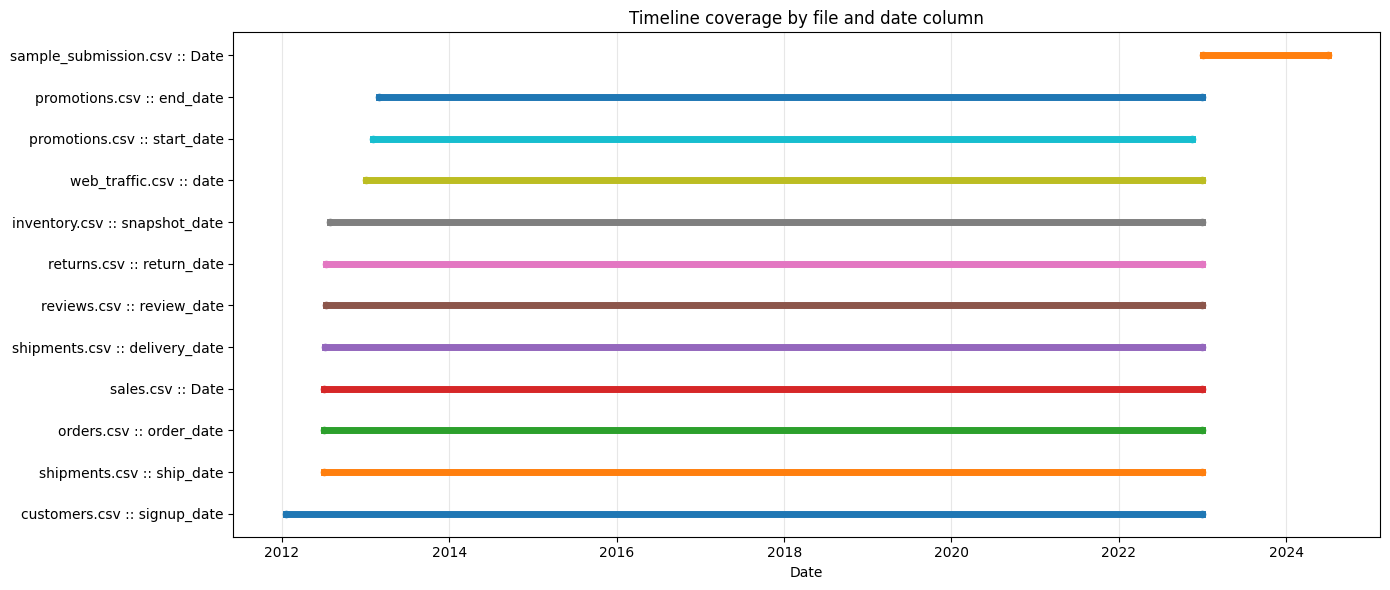

In [9]:
if len(date_summary_df) == 0:
    print("No date-like columns detected; timeline chart skipped.")
else:
    timeline_df = date_summary_df.dropna(subset=["min_date", "max_date"]).copy()
    timeline_df["label"] = timeline_df["file"] + " :: " + timeline_df["date_column"]
    timeline_df = timeline_df.sort_values(["min_date", "max_date", "label"]).reset_index(drop=True)

    fig_height = max(6, 0.38 * len(timeline_df))
    fig, ax = plt.subplots(figsize=(14, fig_height))
    y_positions = np.arange(len(timeline_df))
    starts = pd.to_datetime(timeline_df["min_date"])
    ends = pd.to_datetime(timeline_df["max_date"])

    for y, start, end in zip(y_positions, starts, ends):
        ax.plot([start, end], [y, y], linewidth=5)
        ax.scatter([start, end], [y, y], s=20)

    ax.set_yticks(y_positions)
    ax.set_yticklabels(timeline_df["label"])
    ax.set_title("Timeline coverage by file and date column")
    ax.set_xlabel("Date")
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

## 10. Missing date heatmap / matrix

For daily tables, summarize missing daily dates by year/month. `sales.csv` is always included if detected; `web_traffic.csv` is included if detected.

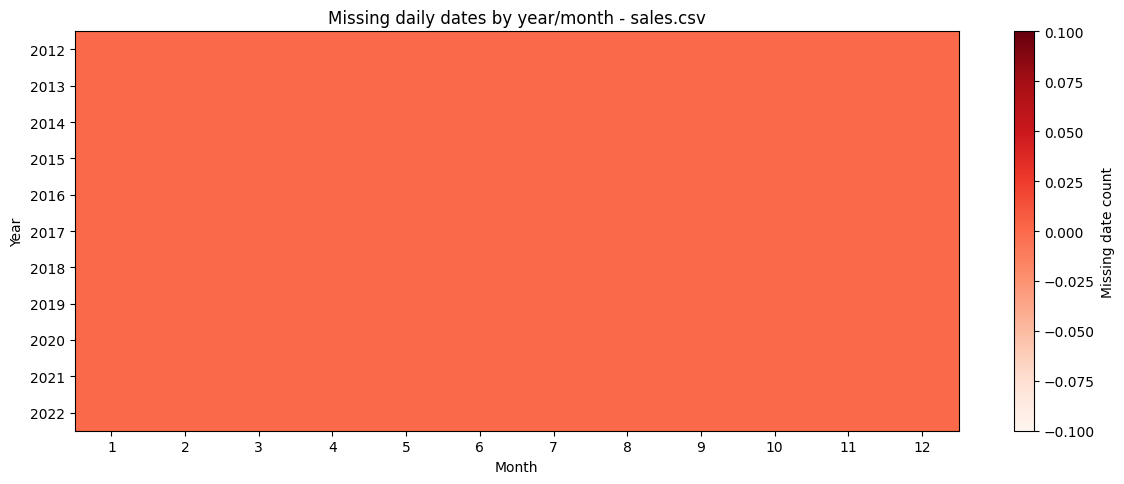

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2012,0,0,0,0,0,0,0,0,0,0,0,0
2013,0,0,0,0,0,0,0,0,0,0,0,0
2014,0,0,0,0,0,0,0,0,0,0,0,0
2015,0,0,0,0,0,0,0,0,0,0,0,0
2016,0,0,0,0,0,0,0,0,0,0,0,0
2017,0,0,0,0,0,0,0,0,0,0,0,0
2018,0,0,0,0,0,0,0,0,0,0,0,0
2019,0,0,0,0,0,0,0,0,0,0,0,0
2020,0,0,0,0,0,0,0,0,0,0,0,0


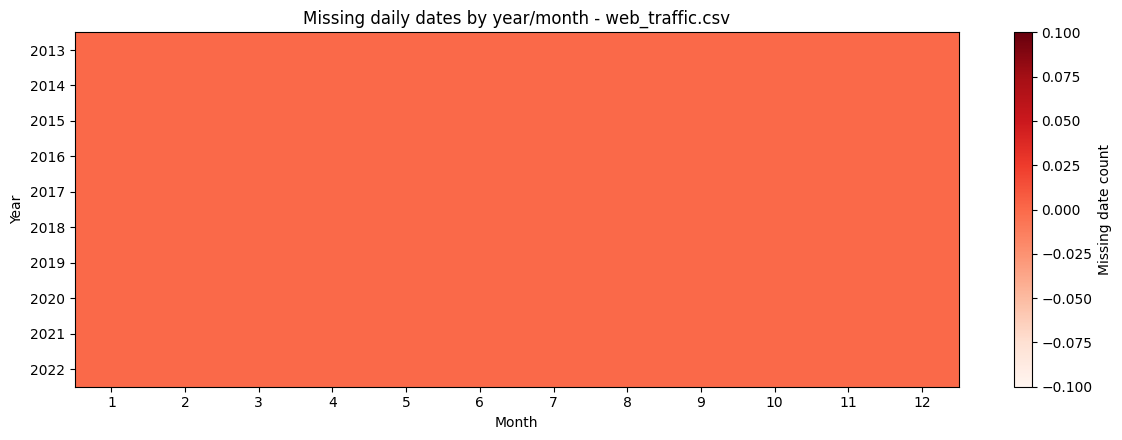

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2013,0,0,0,0,0,0,0,0,0,0,0,0
2014,0,0,0,0,0,0,0,0,0,0,0,0
2015,0,0,0,0,0,0,0,0,0,0,0,0
2016,0,0,0,0,0,0,0,0,0,0,0,0
2017,0,0,0,0,0,0,0,0,0,0,0,0
2018,0,0,0,0,0,0,0,0,0,0,0,0
2019,0,0,0,0,0,0,0,0,0,0,0,0
2020,0,0,0,0,0,0,0,0,0,0,0,0
2021,0,0,0,0,0,0,0,0,0,0,0,0


In [10]:
def missing_daily_matrix(file_name, date_column, expected_start=None, expected_end=None):
    if date_column is None or (file_name, date_column) not in parsed_date_columns:
        return pd.DataFrame()
    dates = parsed_date_columns[(file_name, date_column)].dropna().dt.normalize()
    if len(dates) == 0:
        return pd.DataFrame()
    present = pd.DatetimeIndex(pd.Series(dates.unique()).sort_values())
    start = expected_start if expected_start is not None else present.min()
    end = expected_end if expected_end is not None else present.max()
    expected = pd.date_range(start, end, freq="D")
    missing = expected.difference(present)
    if len(missing) == 0:
        matrix_source = pd.DataFrame({"year": [], "month": [], "missing_count": []})
    else:
        matrix_source = (
            pd.DataFrame({"Date": missing})
            .assign(year=lambda x: x["Date"].dt.year, month=lambda x: x["Date"].dt.month)
            .groupby(["year", "month"])
            .size()
            .reset_index(name="missing_count")
        )
    all_months = pd.DataFrame({"Date": expected}).assign(year=lambda x: x["Date"].dt.year, month=lambda x: x["Date"].dt.month)[["year", "month"]].drop_duplicates()
    matrix_source = all_months.merge(matrix_source, on=["year", "month"], how="left").fillna({"missing_count": 0})
    return matrix_source.pivot(index="year", columns="month", values="missing_count").fillna(0).astype(int)


def plot_matrix(matrix, title):
    if matrix.empty:
        print(f"{title}: no matrix to plot.")
        return
    fig, ax = plt.subplots(figsize=(12, max(3, 0.45 * len(matrix))))
    im = ax.imshow(matrix.values, aspect="auto", cmap="Reds")
    ax.set_xticks(np.arange(len(matrix.columns)))
    ax.set_xticklabels(matrix.columns)
    ax.set_yticks(np.arange(len(matrix.index)))
    ax.set_yticklabels(matrix.index)
    ax.set_xlabel("Month")
    ax.set_ylabel("Year")
    ax.set_title(title)
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            val = matrix.iloc[i, j]
            if val:
                ax.text(j, i, str(val), ha="center", va="center", color="black", fontsize=8)
    fig.colorbar(im, ax=ax, label="Missing date count")
    plt.tight_layout()
    plt.show()
    display(matrix)

sales_missing_matrix = missing_daily_matrix("sales.csv", sales_date_col, EXPECTED_SALES_START, EXPECTED_SALES_END)
plot_matrix(sales_missing_matrix, "Missing daily dates by year/month - sales.csv")

if web_date_col is not None:
    web_missing_matrix = missing_daily_matrix("web_traffic.csv", web_date_col)
    plot_matrix(web_missing_matrix, "Missing daily dates by year/month - web_traffic.csv")
else:
    web_missing_matrix = pd.DataFrame()
    print("web_traffic.csv date column not detected; web missing-date matrix skipped.")

## 11. Record counts by month and year

Plot monthly record counts for major time-series files, and display yearly/monthly count summaries for all detected date columns.

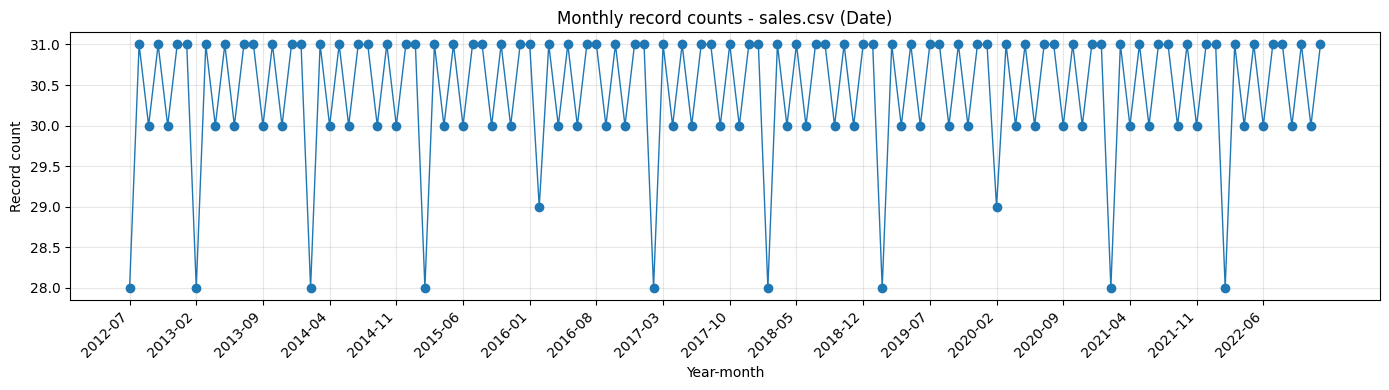

,year_month,record_count
0,2012-07,28
1,2012-08,31
2,2012-09,30
3,2012-10,31
4,2012-11,30
5,2012-12,31
6,2013-01,31
7,2013-02,28
8,2013-03,31
9,2013-04,30


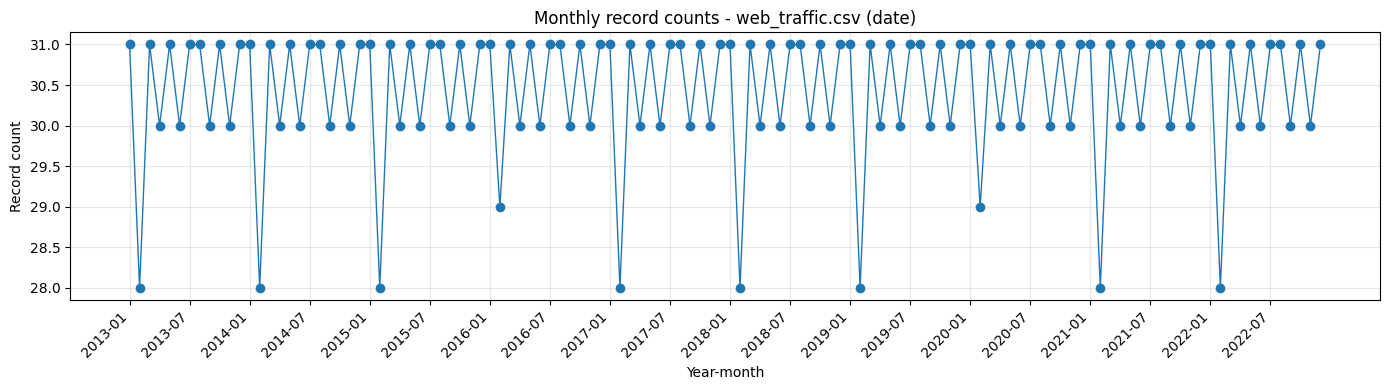

,year_month,record_count
0,2013-01,31
1,2013-02,28
2,2013-03,31
3,2013-04,30
4,2013-05,31
5,2013-06,30
6,2013-07,31
7,2013-08,31
8,2013-09,30
9,2013-10,31


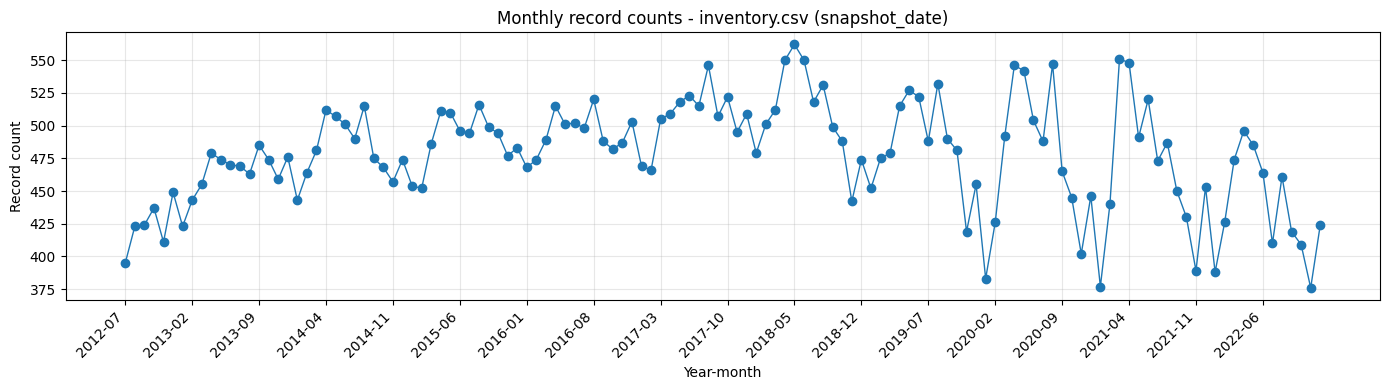

,year_month,record_count
0,2012-07,395
1,2012-08,423
2,2012-09,424
3,2012-10,437
4,2012-11,411
5,2012-12,449
6,2013-01,423
7,2013-02,443
8,2013-03,455
9,2013-04,479


,file,date_column,year,month,record_count
0,customers.csv,signup_date,2012,1,2
1,customers.csv,signup_date,2012,2,21
2,customers.csv,signup_date,2012,3,28
3,customers.csv,signup_date,2012,4,40
4,customers.csv,signup_date,2012,5,67
...,...,...,...,...,...
1248,sample_submission.csv,Date,2024,3,31
1249,sample_submission.csv,Date,2024,4,30
1250,sample_submission.csv,Date,2024,5,31
1251,sample_submission.csv,Date,2024,6,30


In [11]:
def count_by_month(file_name, date_column):
    if date_column is None or (file_name, date_column) not in parsed_date_columns:
        return pd.DataFrame()
    parsed = parsed_date_columns[(file_name, date_column)].dropna().dt.normalize()
    if len(parsed) == 0:
        return pd.DataFrame()
    counts = (
        pd.DataFrame({"Date": parsed})
        .assign(year_month=lambda x: x["Date"].dt.to_period("M").astype(str))
        .groupby("year_month")
        .size()
        .reset_index(name="record_count")
    )
    return counts

major_pairs = [
    ("sales.csv", sales_date_col),
    ("web_traffic.csv", web_date_col),
    ("inventory.csv", inventory_date_col),
]

for file_name, date_column in major_pairs:
    counts = count_by_month(file_name, date_column)
    if counts.empty:
        print(f"No monthly counts available for {file_name}")
        continue
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(counts["year_month"], counts["record_count"], marker="o", linewidth=1)
    ax.set_title(f"Monthly record counts - {file_name} ({date_column})")
    ax.set_xlabel("Year-month")
    ax.set_ylabel("Record count")
    step = max(1, len(counts) // 18)
    ax.set_xticks(np.arange(0, len(counts), step))
    ax.set_xticklabels(counts["year_month"].iloc[::step], rotation=45, ha="right")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    display(counts)

all_year_month_counts = []
for (file_name, date_column), parsed in parsed_date_columns.items():
    valid = parsed.dropna().dt.normalize()
    if len(valid) == 0:
        continue
    counts = (
        pd.DataFrame({"Date": valid})
        .assign(year=lambda x: x["Date"].dt.year, month=lambda x: x["Date"].dt.month)
        .groupby(["year", "month"])
        .size()
        .reset_index(name="record_count")
    )
    counts.insert(0, "date_column", date_column)
    counts.insert(0, "file", file_name)
    all_year_month_counts.append(counts)

all_year_month_counts_df = pd.concat(all_year_month_counts, ignore_index=True) if all_year_month_counts else pd.DataFrame(
    columns=["file", "date_column", "year", "month", "record_count"]
)
all_year_month_counts_df

## 12. Key observations and warnings

Print a concise warning summary covering missing files, no detected date columns, poor date parsing, incomplete coverage, mismatched sales/web coverage, large gaps, and date ranges outside the main business period.

In [12]:
poor_parse_df = date_summary_df[
    date_summary_df["parse_success_rate"].notna()
    & (date_summary_df["parse_success_rate"] < POOR_PARSE_THRESHOLD)
].copy()

incomplete_coverage_df = date_summary_df[
    date_summary_df["missing_period_count"].notna()
    & (date_summary_df["missing_period_count"] > 0)
    & (date_summary_df["apparent_frequency"].isin(["daily", "monthly", "yearly"]))
].copy()

large_gap_df = date_summary_df[date_summary_df["large_gap_count"] > 0].copy()

outside_business_df = date_summary_df[
    date_summary_df["min_date"].notna()
    & date_summary_df["max_date"].notna()
    & ((date_summary_df["min_date"] < MAIN_BUSINESS_START) | (date_summary_df["max_date"] > MAIN_BUSINESS_END))
].copy()

sales_web_mismatch = []
if len(web_sales_comparison_df):
    row = web_sales_comparison_df.iloc[0]
    if not row["web_starts_same_as_sales"]:
        sales_web_mismatch.append("web_traffic.csv starts on a different date than sales.csv")
    if not row["web_ends_same_as_sales"]:
        sales_web_mismatch.append("web_traffic.csv ends on a different date than sales.csv")
    if row["sales_dates_missing_in_web_count"] > 0:
        sales_web_mismatch.append(f"{row['sales_dates_missing_in_web_count']} sales dates are missing in web_traffic.csv")
    if row["web_dates_missing_in_sales_count"] > 0:
        sales_web_mismatch.append(f"{row['web_dates_missing_in_sales_count']} web traffic dates are missing in sales.csv")

print("Warning summary")
print("- Missing CSV files:", missing_files_df["file"].tolist() if len(missing_files_df) else "None")
print("- Files with no detected date-like columns:", files_with_no_date_columns if files_with_no_date_columns else "None")
print(
    "- Files with invalid or poorly parsed date columns:",
    poor_parse_df[["file", "date_column", "parse_success_rate"]].to_dict("records") if len(poor_parse_df) else "None",
)
print(
    "- Date columns with incomplete daily/monthly/yearly coverage:",
    incomplete_coverage_df[["file", "date_column", "apparent_frequency", "missing_period_count", "missing_period_examples"]].to_dict("records") if len(incomplete_coverage_df) else "None",
)
print("- Mismatched coverage between sales.csv and web_traffic.csv:", sales_web_mismatch if sales_web_mismatch else "None")
print(
    "- Large suspicious temporal gaps:",
    large_gap_df[["file", "date_column", "large_gap_count", "large_gap_examples"]].to_dict("records") if len(large_gap_df) else "None",
)
print(
    "- Date ranges outside the main expected business period:",
    outside_business_df[["file", "date_column", "min_date", "max_date"]].to_dict("records") if len(outside_business_df) else "None",
)

print("\nMissing files")
display(missing_files_df if len(missing_files_df) else pd.DataFrame({"message": ["No expected CSV files are missing."]}))

print("\nFiles with no detected date-like columns")
display(files_with_no_date_columns_df if len(files_with_no_date_columns_df) else pd.DataFrame({"message": ["Every loaded file has at least one detected date-like column."]}))

print("\nPoor date parse warnings")
display(poor_parse_df if len(poor_parse_df) else pd.DataFrame({"message": ["No detected date columns have poor parse success."]}))

print("\nIncomplete coverage warnings")
display(incomplete_coverage_df if len(incomplete_coverage_df) else pd.DataFrame({"message": ["No daily/monthly/yearly detected columns have missing periods."]}))

print("\nLarge gap warnings")
display(large_gap_df if len(large_gap_df) else pd.DataFrame({"message": ["No large temporal gaps detected using the configured threshold."]}))

print("\nDate ranges outside main business period")
display(outside_business_df if len(outside_business_df) else pd.DataFrame({"message": ["No detected date ranges fall outside the main business period."]}))

Warning summary
- Missing CSV files: None
- Files with no detected date-like columns: ['products.csv', 'geography.csv', 'order_items.csv', 'payments.csv']
- Files with invalid or poorly parsed date columns: None
- Date columns with incomplete daily/monthly/yearly coverage: [{'file': 'customers.csv', 'date_column': 'signup_date', 'apparent_frequency': 'daily', 'missing_period_count': 61.0, 'missing_period_examples': ['2012-01-18', '2012-01-19', '2012-01-21', '2012-01-22', '2012-01-23', '2012-01-24', '2012-01-25', '2012-01-26', '2012-01-27', '2012-01-28', '2012-01-29', '2012-01-30', '2012-01-31', '2012-02-01', '2012-02-03', '2012-02-04', '2012-02-06', '2012-02-09', '2012-02-10', '2012-02-11']}, {'file': 'returns.csv', 'date_column': 'return_date', 'apparent_frequency': 'daily', 'missing_period_count': 20.0, 'missing_period_examples': ['2012-07-13', '2019-03-09', '2020-02-04', '2020-02-08', '2020-02-23', '2020-03-22', '2020-03-27', '2020-10-28', '2020-11-09', '2021-01-16', '2021-01-25', '

,message
0,No expected CSV files are missing.



Files with no detected date-like columns


,file
0,products.csv
1,geography.csv
2,order_items.csv
3,payments.csv



Poor date parse warnings


...

,file,date_column,detection_reason,dtype_loaded,valid_parsed_dates,invalid_or_unparsed_dates,parse_success_rate,min_date,max_date,unique_dates,apparent_frequency,missing_period_count,missing_period_examples,large_gap_count,large_gap_examples
0,customers.csv,signup_date,name_match;high_parse_success,object,121930,0,1.0,2012-01-17,2022-12-31,3941,daily,61.0,"[2012-01-18, 2012-01-19, 2012-01-21, 2012-01-22, 2012-01-23, 2012-01-24, 2012-01-25, 2012-01-26, 2012-01-27, 2012-01-28, 2012-01-29, 2012-01-30, 2012-01-31,...",0,[]
5,returns.csv,return_date,name_match;high_parse_success,object,39939,0,1.0,2012-07-11,2022-12-31,3806,daily,20.0,"[2012-07-13, 2019-03-09, 2020-02-04, 2020-02-08, 2020-02-23, 2020-03-22, 2020-03-27, 2020-10-28, 2020-11-09, 2021-01-16, 2021-01-25, 2021-02-19, 2021-10-06,...",0,[]
6,reviews.csv,review_date,name_match;high_parse_success,object,113551,0,1.0,2012-07-10,2022-12-31,3825,daily,2.0,"[2012-07-11, 2021-02-22]",0,[]



Large gap warnings


,file,date_column,detection_reason,dtype_loaded,valid_parsed_dates,invalid_or_unparsed_dates,parse_success_rate,min_date,max_date,unique_dates,apparent_frequency,missing_period_count,missing_period_examples,large_gap_count,large_gap_examples
3,promotions.csv,end_date,name_match;high_parse_success,object,50,0,1.0,2013-03-01,2022-12-31,50,irregular,NaN,[],10,"[{'previous_date': '2013-03-01', 'next_date': '2013-04-17', 'gap_days': 47}, {'previous_date': '2013-04-17', 'next_date': '2013-07-22', 'gap_days': 96}, {'p..."
4,promotions.csv,start_date,name_match;high_parse_success,object,50,0,1.0,2013-01-31,2022-11-18,50,irregular,NaN,[],10,"[{'previous_date': '2013-01-31', 'next_date': '2013-03-18', 'gap_days': 46}, {'previous_date': '2013-03-18', 'next_date': '2013-06-23', 'gap_days': 97}, {'p..."



Date ranges outside main business period


,file,date_column,detection_reason,dtype_loaded,valid_parsed_dates,invalid_or_unparsed_dates,parse_success_rate,min_date,max_date,unique_dates,apparent_frequency,missing_period_count,missing_period_examples,large_gap_count,large_gap_examples
0,customers.csv,signup_date,name_match;high_parse_success,object,121930,0,1.0,2012-01-17,2022-12-31,3941,daily,61.0,"[2012-01-18, 2012-01-19, 2012-01-21, 2012-01-22, 2012-01-23, 2012-01-24, 2012-01-25, 2012-01-26, 2012-01-27, 2012-01-28, 2012-01-29, 2012-01-30, 2012-01-31,...",0,[]
8,sample_submission.csv,Date,name_match;high_parse_success,object,548,0,1.0,2023-01-01,2024-07-01,548,daily,0.0,[],0,[]
